In [1]:
import pandas as pd
from pathlib import Path
import tarfile
import urllib.request
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
def load_housing_data():
  tarball_path=Path("datasets/housing.tgz")
  if not tarball_path.is_file():
    Path("datasets").mkdir(parents=True,exist_ok=True)
    url="https://github.com/ageron/data/raw/main/housing.tgz"
    urllib.request.urlretrieve(url,tarball_path)
    with tarfile.open(tarball_path) as housing_tarball:
      housing_tarball.extractall(path="datasets")
  return pd.read_csv(Path("datasets/housing/housing.csv"))
housing=load_housing_data()

/tmp/ipython-input-1280470021.py:8: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  housing_tarball.extractall(path="datasets")


In [3]:
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [4]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [5]:
housing["ocean_proximity"].value_counts()

,count
ocean_proximity,
<1H OCEAN,9136
INLAND,6551
NEAR OCEAN,2658
NEAR BAY,2290
ISLAND,5


In [6]:
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


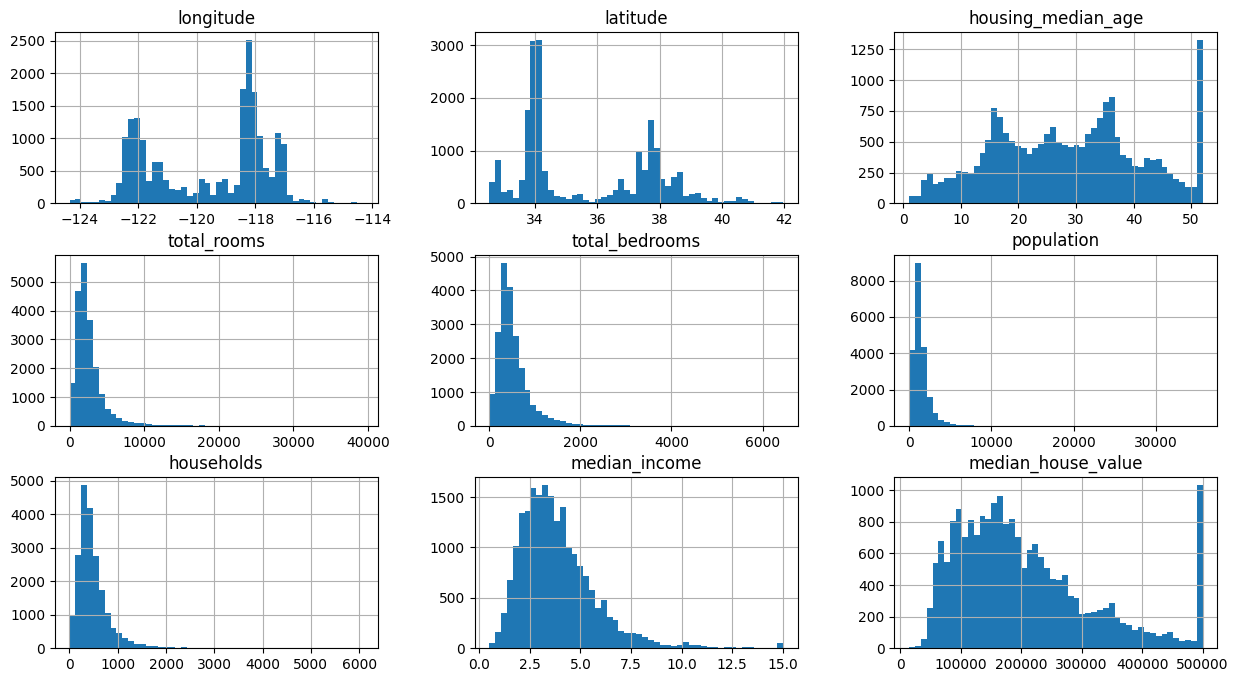

In [7]:
housing.hist(bins=50,figsize=(15,8))
plt.show()

In [8]:
import numpy as np

def shuffle_and_split_data(data, test_ratio):
    shuffled_indices = np.random.permutation(len(data))
    test_set_size = int(len(data) * test_ratio)
    test_indices = shuffled_indices[:test_set_size]
    train_indices = shuffled_indices[test_set_size:]
    return data.iloc[train_indices], data.iloc[test_indices]

# You can then use this function like this:
# >>> train_set, test_set = shuffle_and_split_data(housing, 0.2)
# >>> len(train_set)
# 16512
# >>> len(test_set)
# 4128


In [9]:
def shuffle_and_split_data(data,test_ratio):
  shuffled_indices=np.random.permutation(len(data))
  test_set_size=int(len(data)*test_ratio)
  test_indices=shuffled_indices[:test_set_size]
  train_indices=shuffled_indices[test_set_size:]
  return data.iloc[train_indices],data.iloc[test_indices]

In [10]:
  train_set,test_set=shuffle_and_split_data(housing,.2)

In [11]:
len(train_set)

16512

In [12]:
len(test_set)

4128

In [13]:
from zlib import crc32
import numpy as np
import pandas as pd
def is_id_in_test_set(identifier,test_ratio):
  return crc32(np.int64(identifier))<test_ratio*2**32
def split_data_with_id_hash(data,test_ratio,id_column):
  ids=data[id_column]
  in_test_set=ids.apply(lambda id: is_id_in_test_set(id,test_ratio))
  return data.loc[~in_test_set],data.loc[in_test_set]


In [14]:
housing_with_id=housing.reset_index()
train_set,test_set=split_data_with_id_hash(housing_with_id,0.2,"index")

In [15]:
housing_with_id["id"]=housing["longitude"]*1000+housing["latitude"]
train_set,test_set=split_data_with_id_hash(housing_with_id,0.2,"id")

In [16]:
from sklearn.model_selection import train_test_split
train_set,test_set=train_test_split(housing,test_size=0.2,random_state=42)

In [17]:
housing["income_cat"]=pd.cut(housing["median_income"],bins=[0,1.5,3.0,4.5,6,np.inf],labels=[1,2,3,4,5])

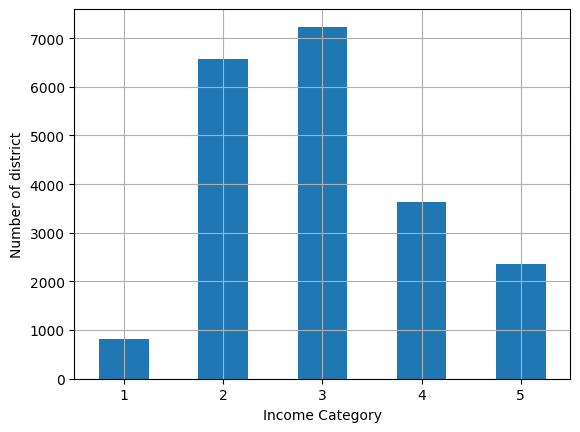

In [18]:
housing["income_cat"].value_counts().sort_index().plot.bar(rot=0,grid=True)
plt.xlabel("Income Category")
plt.ylabel("Number of district")
plt.show()

In [19]:
from sklearn.model_selection import StratifiedShuffleSplit
splitter=StratifiedShuffleSplit(n_splits=10,test_size=10,random_state=42)
strat_splits=[]
for train_index,test_index in splitter.split(housing,housing["income_cat"]):
  strat_train_set_n=housing.iloc[train_index]
  strat_test_set_n=housing.iloc[test_index]
  strat_splits.append([strat_train_set_n,strat_test_set_n])

In [20]:
strat_train_set,strat_test_set=strat_splits[0]

In [21]:
strat_train_set,strat_test_set=train_test_split(
    housing,test_size=.2,stratify=housing["income_cat"],random_state=42
)

In [22]:
strat_test_set["income_cat"].value_counts()/len(strat_test_set)

,count
income_cat,
3,0.350533
2,0.318798
4,0.176357
5,0.114341
1,0.039971


In [23]:
for set_ in(strat_train_set,strat_test_set):
  set_.drop("income_cat",axis=1,inplace=True)

In [24]:
housing=strat_train_set.copy()

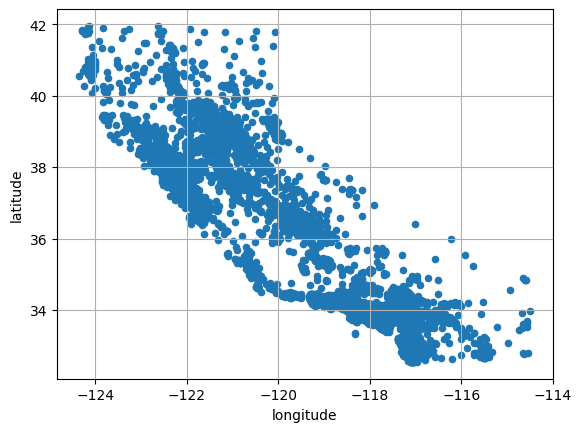

In [25]:
housing.plot(kind="scatter",x="longitude",y="latitude",grid=True)
plt.show()

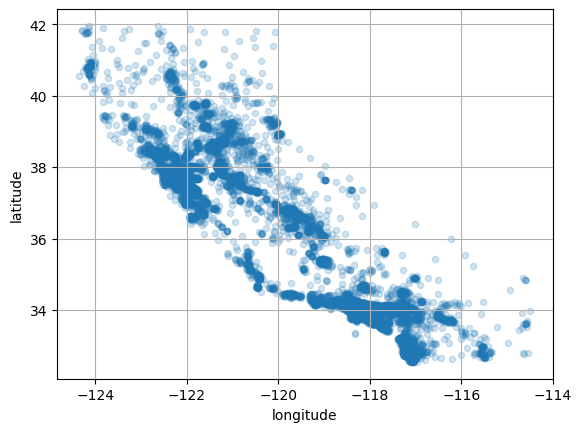

In [26]:
housing.plot(kind="scatter",x="longitude",y="latitude",grid=True,alpha=0.2)
plt.show()

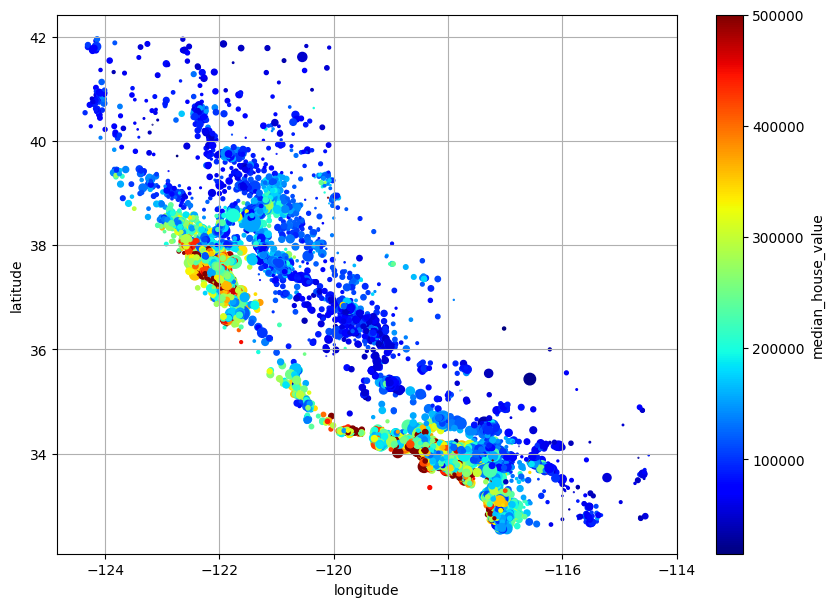

In [27]:
housing.plot(kind="scatter",x="longitude",y="latitude",grid=True,s=housing["population"]/100,
             c="median_house_value",cmap=plt.get_cmap("jet"),colorbar=True,legend=True,sharex=False,figsize=(10,7)
             )
plt.show()

In [28]:
corr_matrix=housing.drop("ocean_proximity",axis=1).corr()

In [29]:
corr_matrix["median_house_value"].sort_values(ascending=False)

,median_house_value
median_house_value,1.000000
median_income,0.688380
total_rooms,0.137455
housing_median_age,0.102175
households,0.071426
total_bedrooms,0.054635
population,-0.020153
longitude,-0.050859
latitude,-0.139584


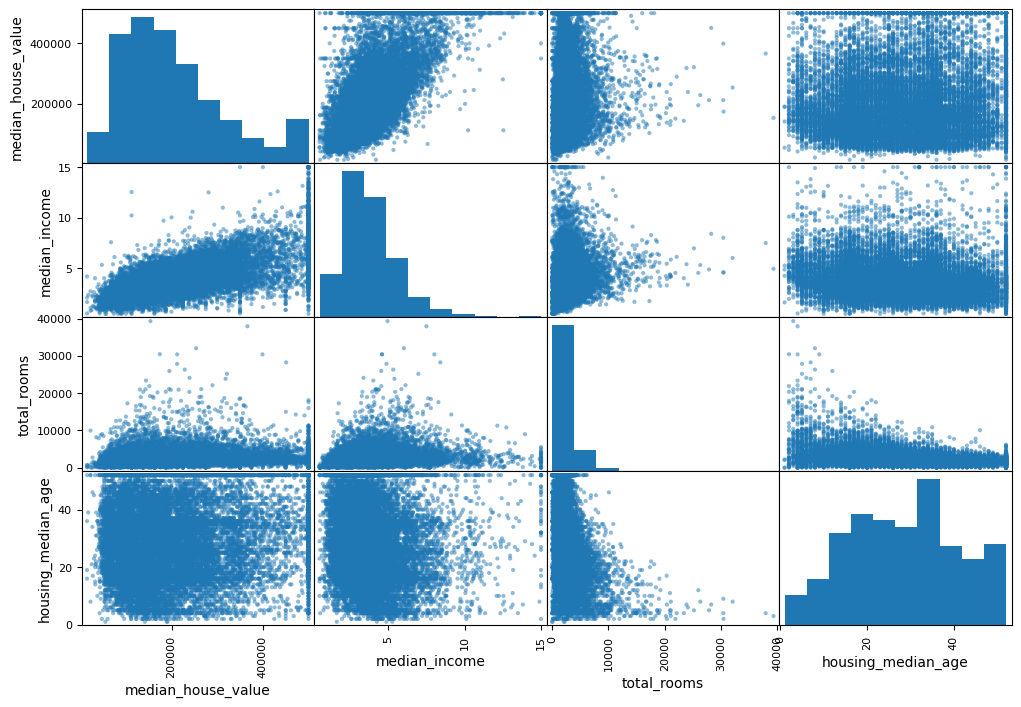

In [30]:
from pandas.plotting import scatter_matrix
attributes=["median_house_value","median_income","total_rooms","housing_median_age"]
scatter_matrix(housing[attributes],figsize=(12,8))
plt.show()

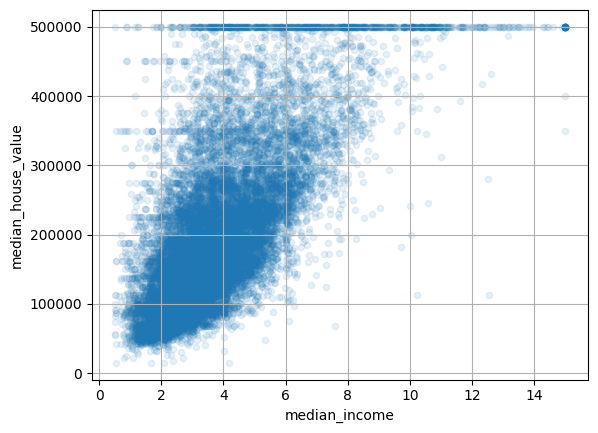

In [31]:
housing.plot(kind="scatter",x="median_income",y="median_house_value",alpha=0.1,grid=True)
plt.show()

In [32]:
housing["rooms_per_household"]=housing["total_rooms"]/housing["households"]
housing["bedrooms_ratio"]=housing["total_bedrooms"]/housing["total_rooms"]
housing["population_per_house"]=housing["population"]/housing["households"]

In [33]:
corr_matrix=housing.drop("ocean_proximity",axis=1).corr()
corr_matrix["median_house_value"].sort_values(ascending=False)

,median_house_value
median_house_value,1.000000
median_income,0.688380
rooms_per_household,0.143663
total_rooms,0.137455
housing_median_age,0.102175
households,0.071426
total_bedrooms,0.054635
population,-0.020153
population_per_house,-0.038224
longitude,-0.050859


In [34]:
housing=strat_train_set.drop("median_house_value",axis=1)
housing_labels=strat_train_set["median_house_value"].copy()

In [35]:
median=housing["total_bedrooms"].median()
housing["total_bedrooms"].fillna(median,inplace=True)

/tmp/ipython-input-697158927.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  housing["total_bedrooms"].fillna(median,inplace=True)


In [36]:
from sklearn.impute import SimpleImputer
imputer=SimpleImputer(strategy="median")

In [37]:
housing_num=housing.select_dtypes(include=[np.number])

In [38]:
imputer.fit(housing_num)

SimpleImputer(strategy='median')

In [39]:
imputer.statistics_

array([-118.51  ,   34.26  ,   29.    , 2125.    ,  434.    , 1167.    ,
        408.    ,    3.5385])

In [40]:
housing_num.median().values

array([-118.51  ,   34.26  ,   29.    , 2125.    ,  434.    , 1167.    ,
        408.    ,    3.5385])

In [41]:
x=imputer.transform(housing_num)

In [42]:
housing_tr=pd.DataFrame(x,columns=housing_num.columns,index=housing_num.index)

In [43]:
housing_cat=housing[["ocean_proximity"]]

In [44]:
housing_cat.head(8)

,ocean_proximity
13096,NEAR BAY
14973,<1H OCEAN
3785,INLAND
14689,INLAND
20507,NEAR OCEAN
1286,INLAND
18078,<1H OCEAN
4396,NEAR BAY


In [45]:
from sklearn.preprocessing import OrdinalEncoder
ordinal_encoder=OrdinalEncoder()
housing_cat_encoded=ordinal_encoder.fit_transform(housing_cat)

In [46]:
housing_cat_encoded[:8]

array([[3.],
       [0.],
       [1.],
       [1.],
       [4.],
       [1.],
       [0.],
       [3.]])

In [47]:
ordinal_encoder.categories_

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

In [48]:
from sklearn.preprocessing import OneHotEncoder
cat_encoder=OneHotEncoder()
housing_cat_1hot=cat_encoder.fit_transform(housing_cat)

In [49]:
housing_cat_1hot

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 16512 stored elements and shape (16512, 5)>

In [50]:
housing_cat_1hot.toarray()

array([[0., 0., 0., 1., 0.],
       [1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0.],
       ...,
       [0., 0., 0., 0., 1.],
       [1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1.]])

In [51]:
cat_encoder.categories_

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

In [52]:
df_test=pd.DataFrame({"ocean_proximity":["INLAND","NEAR BAY"]})

In [53]:
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
13096,-122.42,37.80,52.0,3321.0,1115.0,1576.0,1034.0,2.0987,NEAR BAY
14973,-118.38,34.14,40.0,1965.0,354.0,666.0,357.0,6.0876,<1H OCEAN
3785,-121.98,38.36,33.0,1083.0,217.0,562.0,203.0,2.4330,INLAND
14689,-117.11,33.75,17.0,4174.0,851.0,1845.0,780.0,2.2618,INLAND
20507,-118.15,33.77,36.0,4366.0,1211.0,1912.0,1172.0,3.5292,NEAR OCEAN


In [54]:
pd.get_dummies(df_test)

,ocean_proximity_INLAND,ocean_proximity_NEAR BAY
0,True,False
1,False,True


In [55]:
cat_encoder.transform(df_test)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 2 stored elements and shape (2, 5)>

In [56]:
df_test_unknown=pd.DataFrame({"ocean_proximity":["<2H OCEAN","ISLAND"]})

In [57]:
pd.get_dummies(df_test_unknown)

,ocean_proximity_<2H OCEAN,ocean_proximity_ISLAND
0,True,False
1,False,True


In [58]:
cat_encoder.handle_unknown="ignore"

In [59]:
cat_encoder.transform(df_test_unknown)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 1 stored elements and shape (2, 5)>

In [60]:
cat_encoder.feature_names_in_

array(['ocean_proximity'], dtype=object)

In [61]:
cat_encoder.get_feature_names_out()

array(['ocean_proximity_<1H OCEAN', 'ocean_proximity_INLAND',
       'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY',
       'ocean_proximity_NEAR OCEAN'], dtype=object)

# feature scaling and transformation

In [62]:
from sklearn.preprocessing import MinMaxScaler
MinMaxScaler=MinMaxScaler(feature_range=(-1,1))
housing_num_min_max_scaled=MinMaxScaler.fit_transform(housing_num)

In [63]:
from sklearn.preprocessing import StandardScaler
std_scaler=StandardScaler()
housing_num_std_scaled=std_scaler.fit_transform(housing_num)

In [64]:
from sklearn.metrics.pairwise import rbf_kernel
age_simil_35=rbf_kernel(housing[["housing_median_age"]],[[35]],gamma=0.1)

In [65]:
from sklearn.linear_model import LinearRegression
target_scaler=StandardScaler()
scaled_labels=target_scaler.fit_transform(housing_labels.to_frame())
model=LinearRegression()
model.fit(housing[["median_income"]],scaled_labels)
some_new_data=housing[["median_income"]].iloc[:5]

In [66]:
scaled_predictions=model.predict(some_new_data)
predictions=target_scaler.inverse_transform(scaled_predictions)

In [67]:
from sklearn.compose import TransformedTargetRegressor
model=TransformedTargetRegressor(
    LinearRegression(),
    transformer=StandardScaler(),
)
model.fit(housing[["median_income"]],housing_labels)
predictions=model.predict(some_new_data)

In [68]:
from sklearn.preprocessing import FunctionTransformer
model=FunctionTransformer
log_transformer=FunctionTransformer(np.log,inverse_func=np.exp)
log_pop=log_transformer.transform(housing[["population"]])

In [69]:
rbf_transformer=FunctionTransformer(rbf_kernel,kw_args=dict(Y=[[35.]],gamma=0.1))
age_simil_35=rbf_transformer.transform(housing[["housing_median_age"]])

In [70]:
sf_coords=37.7749,-122.41
sf_transformer=FunctionTransformer(rbf_kernel,kw_args=dict(Y=[sf_coords],gamma=0.1))
sf_simil=sf_transformer.transform(housing[["latitude","longitude"]])

In [71]:
ratio_transformer=FunctionTransformer(lambda X : X[:,[0]]/X[:,[1]])
ratio_transformer.transform(np.array([[1,2],[3,4]] ))

array([[0.5 ],
       [0.75]])

In [72]:
from sklearn.base import BaseEstimator,TransformerMixin
from sklearn.utils.validation import check_array,check_is_fitted
class StandardScalerClone(BaseEstimator,TransformerMixin):
    def __init__(self,with_mean=True):
        self.with_mean=with_mean
    def fit(self,x,y=None):
        x=check_array(x)
        self.mean_=x.mean(axis=0)
        self.scale_=x.std(axis=0)
        self.n_features_in_=x.shape[1]
        return self
    def transform(self,x):
        check_is_fitted(self)
        x=check_array(x)
        assert self.n_features_in_==x.shape[1]
        if self.with_mean:
            x=x-self.mean_
        return x/self.scale_

In [73]:
from sklearn.cluster import KMeans
from sklearn.base import BaseEstimator,TransformerMixin
from sklearn.metrics.pairwise import rbf_kernel

class ClusterSimilarity(BaseEstimator,TransformerMixin):
  def __init__(self,n_clusters=10,gamma=1.0,random_state=None):
    self.n_clusters=n_clusters
    self.gamma=gamma
    self.random_state=random_state

  def fit(self,x,y=None,sample_weight=None):
    self.kmeans_=KMeans(n_clusters=self.n_clusters,random_state=self.random_state,n_init=10)
    self.kmeans_.fit(x,sample_weight=sample_weight)
    return self

  def transform(self,x):
    return rbf_kernel(x,self.kmeans_.cluster_centers_,gamma=self.gamma)

  def get_feature_names_out(self,names=None):
    return [f"Cluster{i} similarity" for i in range(self.n_clusters)]

In [74]:
cluster_simil=ClusterSimilarity(n_clusters=10,gamma=1.0,random_state=42)
similarity=cluster_simil.fit_transform(housing[["latitude","longitude"]],sample_weight=housing_labels)

In [75]:
similarity[:3].round(2)

array([[0.08, 0.  , 0.6 , 0.  , 0.  , 0.99, 0.  , 0.  , 0.  , 0.14],
       [0.  , 0.99, 0.  , 0.04, 0.  , 0.  , 0.11, 0.  , 0.63, 0.  ],
       [0.44, 0.  , 0.3 , 0.  , 0.  , 0.7 , 0.  , 0.01, 0.  , 0.29]])

Transformation Pipeline

In [76]:
from sklearn.pipeline import Pipeline
num_pipeline=Pipeline([
    ("impute",SimpleImputer(strategy="median")),
    ("Standardize",StandardScaler()),
])

In [77]:
import sklearn

In [78]:
sklearn.set_config(display="diagram")

In [79]:
num_pipeline

Pipeline(steps=[('impute', SimpleImputer(strategy='median')),
                ('Standardize', StandardScaler())])

In [80]:
from sklearn.pipeline import make_pipeline
num_pipeline=make_pipeline(SimpleImputer(strategy="median"),StandardScaler())

In [81]:
housing_num_prepared=num_pipeline.fit_transform(housing_num)
housing_num_prepared[:2].round(2)

array([[-1.42,  1.01,  1.86,  0.31,  1.37,  0.14,  1.39, -0.94],
       [ 0.6 , -0.7 ,  0.91, -0.31, -0.44, -0.69, -0.37,  1.17]])

In [82]:
df_housing_num_prepared=pd.DataFrame(housing_num_prepared,columns=num_pipeline.get_feature_names_out(),index=housing_num.index)

In [83]:
from sklearn.compose import ColumnTransformer
num_attribs=["longitude","latitude","housing_median_age",	"total_rooms",	"total_bedrooms","	population	","households	","median_income"]
cat_attribs=["ocean_proximity"]

In [84]:
cat_pipeline=make_pipeline(
    SimpleImputer(strategy="most_frequent"),
    OneHotEncoder(handle_unknown="ignore"))
preprocessing=ColumnTransformer([
    ("num",num_pipeline,num_attribs),
    ("cat",cat_pipeline,cat_attribs)
])

In [85]:
from sklearn.compose import make_column_selector,make_column_transformer
preprocessing=make_column_transformer(
    (num_pipeline,make_column_selector(dtype_include=np.number)),
    (cat_pipeline,make_column_selector(dtype_include=object)),
)

In [86]:
housing_prepared=preprocessing.fit_transform(housing)

In [87]:
def column_ratio(x):
  return x[:,[0]]/x[:,[1]]
def ratio_name(function_transformer,feature_names_in):
  return["ratio"]
def ratio_pipeline():
  return make_pipeline(
      SimpleImputer(strategy="median"),
      FunctionTransformer(column_ratio,feature_names_out=ratio_name),
      StandardScaler(),
  )
log_pipeline=make_pipeline(
    SimpleImputer(strategy="median"),
    FunctionTransformer(np.log,feature_names_out="one-to-one"),
    StandardScaler()
)
cluster_simil=ClusterSimilarity(n_clusters=10,gamma=1,random_state=42)
default_num_pipeline=make_pipeline(
    SimpleImputer(strategy="median"),
    StandardScaler()
)

In [88]:
preprocessing=ColumnTransformer([
    ("bedrooms",ratio_pipeline(),["total_bedrooms","total_rooms"]),
    ("room_per_house",ratio_pipeline(),["total_rooms","households"]),
    ("population_per_house",ratio_pipeline(),["population","households"]),
    ("log",log_pipeline,["housing_median_age","total_rooms","total_bedrooms","population","households","median_income"]),
    ("geo",cluster_simil,["latitude","longitude"]),
    ("cat",cat_pipeline,make_column_selector(dtype_include=object)),
],remainder=default_num_pipeline)

In [89]:
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
13096,-122.42,37.80,52.0,3321.0,1115.0,1576.0,1034.0,2.0987,NEAR BAY
14973,-118.38,34.14,40.0,1965.0,354.0,666.0,357.0,6.0876,<1H OCEAN
3785,-121.98,38.36,33.0,1083.0,217.0,562.0,203.0,2.4330,INLAND
14689,-117.11,33.75,17.0,4174.0,851.0,1845.0,780.0,2.2618,INLAND
20507,-118.15,33.77,36.0,4366.0,1211.0,1912.0,1172.0,3.5292,NEAR OCEAN


In [90]:
housing_prepared=preprocessing.fit_transform(housing)
housing_prepared.shape
preprocessing.get_feature_names_out()

array(['bedrooms__ratio', 'room_per_house__ratio',
       'population_per_house__ratio', 'log__housing_median_age',
       'log__total_rooms', 'log__total_bedrooms', 'log__population',
       'log__households', 'log__median_income',
       'geo__Cluster0 similarity', 'geo__Cluster1 similarity',
       'geo__Cluster2 similarity', 'geo__Cluster3 similarity',
       'geo__Cluster4 similarity', 'geo__Cluster5 similarity',
       'geo__Cluster6 similarity', 'geo__Cluster7 similarity',
       'geo__Cluster8 similarity', 'geo__Cluster9 similarity',
       'cat__ocean_proximity_<1H OCEAN', 'cat__ocean_proximity_INLAND',
       'cat__ocean_proximity_ISLAND', 'cat__ocean_proximity_NEAR BAY',
       'cat__ocean_proximity_NEAR OCEAN'], dtype=object)

Select and train model

In [91]:
from sklearn.linear_model import LinearRegression
lin_reg=make_pipeline(preprocessing,LinearRegression())
lin_reg.fit(housing,housing_labels)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder=Pipeline(steps=[('simpleimputer',
                                                              SimpleImputer(strategy='median')),
                                                             ('standardscaler',
                                                              StandardScaler())]),
                                   transformers=[('bedrooms',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('functiontransformer',
                                                                   FunctionTransformer(feature_names_out=<function ratio_name at 0x7cb...
                                                   'median_income']),
                                                 ('geo',
                                                  ClusterSimilarity(gamma=1,
                                                                    random_state=42),
                                                  ['latitude', 'longitude']),
                                                 ('cat',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7cb4c6221fd0>)])),
                ('linearregression', LinearRegression())])

In [92]:
housing_predictions=lin_reg.predict(housing)
housing_predictions[:5].round(-2)
housing_labels.iloc[:5].values

array([458300., 483800., 101700.,  96100., 361800.])

In [93]:
from sklearn.metrics import mean_squared_error
import numpy as np
lin_rmse=np.sqrt(mean_squared_error(housing_labels,housing_predictions))
lin_rmse

np.float64(68715.24817910878)

In [94]:
from sklearn.tree import DecisionTreeRegressor
tree_reg=make_pipeline(preprocessing,DecisionTreeRegressor(random_state=42))
tree_reg.fit(housing,housing_labels)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder=Pipeline(steps=[('simpleimputer',
                                                              SimpleImputer(strategy='median')),
                                                             ('standardscaler',
                                                              StandardScaler())]),
                                   transformers=[('bedrooms',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('functiontransformer',
                                                                   FunctionTransformer(feature_names_out=<function ratio_name at 0x7cb...
                                                  ClusterSimilarity(gamma=1,
                                                                    random_state=42),
                                                  ['latitude', 'longitude']),
                                                 ('cat',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7cb4c6221fd0>)])),
                ('decisiontreeregressor',
                 DecisionTreeRegressor(random_state=42))])

In [95]:
housing_labels.head()

,median_house_value
13096,458300.0
14973,483800.0
3785,101700.0
14689,96100.0
20507,361800.0


In [96]:
housing_predictions=tree_reg.predict(housing)
tree_rmse=np.sqrt(mean_squared_error(housing_labels,housing_predictions))

In [97]:
tree_rmse

np.float64(0.0)

Better Evaluation Using Cross Validation

In [98]:
from sklearn.model_selection import cross_val_score
tree_rmse=-cross_val_score(tree_reg,housing,housing_labels,scoring="neg_root_mean_squared_error",cv=10)

In [99]:
pd.Series(tree_rmse).describe()

,0
count,10.000000
mean,66187.259723
std,2135.111988
min,62462.623015
25%,65893.700244
50%,66282.598438
75%,67844.305540
max,68635.246843


In [100]:
from sklearn.ensemble import RandomForestRegressor
forest_reg=make_pipeline(preprocessing,RandomForestRegressor(random_state=42))
forest_rmses=-cross_val_score(forest_reg,housing,housing_labels,scoring="neg_root_mean_squared_error",cv=10)

In [101]:
pd.Series(forest_rmses).describe()

,0
count,10.000000
mean,46910.305125
std,1072.696230
min,45517.323267
25%,46190.825575
50%,46909.686168
75%,47339.647328
max,49314.077460


Fine Tune Your Model

In [102]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
full_pipeline=Pipeline([
    ("preprocessing",preprocessing),
    ("random_forest",RandomForestRegressor(random_state=42))
])
param_grid=[
    {'preprocessing__geo__n_clusters':[5,8,10],'random_forest__max_features':[4,6,8]},
    {'preprocessing__geo__n_clusters':[10,15],'random_forest__max_features':[6,8,10]},
]
grid_search=GridSearchCV(full_pipeline,param_grid,cv=3,scoring='neg_root_mean_squared_error')
grid_search.fit(housing,housing_labels)

GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('preprocessing',
                                        ColumnTransformer(remainder=Pipeline(steps=[('simpleimputer',
                                                                                     SimpleImputer(strategy='median')),
                                                                                    ('standardscaler',
                                                                                     StandardScaler())]),
                                                          transformers=[('bedrooms',
                                                                         Pipeline(steps=[('simpleimputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('functiontransformer',
                                                                                          FunctionTransformer(feature_names_out=<f...
                                                                         <sklearn.compose._column_transformer.make_column_selector object at 0x7cb4c6221fd0>)])),
                                       ('random_forest',
                                        RandomForestRegressor(random_state=42))]),
             param_grid=[{'preprocessing__geo__n_clusters': [5, 8, 10],
                          'random_forest__max_features': [4, 6, 8]},
                         {'preprocessing__geo__n_clusters': [10, 15],
                          'random_forest__max_features': [6, 8, 10]}],
             scoring='neg_root_mean_squared_error')

In [103]:
grid_search.best_params_

{'preprocessing__geo__n_clusters': 15, 'random_forest__max_features': 6}

In [104]:
grid_search.best_estimator_

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder=Pipeline(steps=[('simpleimputer',
                                                              SimpleImputer(strategy='median')),
                                                             ('standardscaler',
                                                              StandardScaler())]),
                                   transformers=[('bedrooms',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('functiontransformer',
                                                                   FunctionTransformer(feature_names_out=<function ratio_name at 0x7cb4c61...
                                                                    n_clusters=15,
                                                                    random_state=42),
                                                  ['latitude', 'longitude']),
                                                 ('cat',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7cb4c6463410>)])),
                ('random_forest',
                 RandomForestRegressor(max_features=6, random_state=42))])

In [105]:
cv_res=pd.DataFrame(grid_search.cv_results_)
cv_res.sort_values(by="mean_test_score",ascending=False,inplace=True)
cv_res.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_preprocessing__geo__n_clusters,param_random_forest__max_features,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
12,10.466471,0.153691,0.246976,0.048681,15,6,"{'preprocessing__geo__n_clusters': 15, 'random...",-42981.338503,-43435.225351,-44540.827897,-43652.463917,654.928107,1
13,13.540089,0.130809,0.203548,0.009756,15,8,"{'preprocessing__geo__n_clusters': 15, 'random...",-43244.781114,-43872.198729,-44542.378012,-43886.452618,529.837590,2
6,7.119231,0.209568,0.196587,0.013646,10,4,"{'preprocessing__geo__n_clusters': 10, 'random...",-43373.552869,-44092.464126,-44993.984360,-44153.333785,662.937096,3
14,16.584466,0.311931,0.219631,0.036424,15,10,"{'preprocessing__geo__n_clusters': 15, 'random...",-44242.859663,-44341.319259,-45224.045496,-44602.741473,441.163303,4
7,9.947034,0.213900,0.229341,0.033978,10,6,"{'preprocessing__geo__n_clusters': 10, 'random...",-44193.442977,-44343.467999,-45418.941809,-44651.950928,545.791862,5


Randomized Search

In [106]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint
param_distribs={'preprocessing__geo__n_clusters':randint(low=3,high=50),'random_forest__max_features':randint(low=2,high=20)}
rnd_search=RandomizedSearchCV(full_pipeline,param_distributions=param_distribs,n_iter=10,cv=3,scoring='neg_root_mean_squared_error',random_state=42)
rnd_search.fit(housing,housing_labels)

RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('preprocessing',
                                              ColumnTransformer(remainder=Pipeline(steps=[('simpleimputer',
                                                                                           SimpleImputer(strategy='median')),
                                                                                          ('standardscaler',
                                                                                           StandardScaler())]),
                                                                transformers=[('bedrooms',
                                                                               Pipeline(steps=[('simpleimputer',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('functiontransformer',
                                                                                                FunctionTransformer(feature_names_...
                                             ('random_forest',
                                              RandomForestRegressor(random_state=42))]),
                   param_distributions={'preprocessing__geo__n_clusters': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7cb4c6945e80>,
                                        'random_forest__max_features': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7cb4c3e1af00>},
                   random_state=42, scoring='neg_root_mean_squared_error')

Analyzing the best models and thier error

In [107]:
final_model=rnd_search.best_estimator_
feature_importances=final_model["random_forest"].feature_importances_
feature_importances.round(2)

array([0.07, 0.05, 0.05, 0.01, 0.01, 0.01, 0.01, 0.01, 0.19, 0.01, 0.01,
       0.01, 0.04, 0.01, 0.  , 0.02, 0.01, 0.01, 0.  , 0.02, 0.01, 0.  ,
       0.01, 0.01, 0.01, 0.01, 0.03, 0.02, 0.01, 0.01, 0.02, 0.03, 0.01,
       0.01, 0.01, 0.01, 0.01, 0.01, 0.  , 0.01, 0.02, 0.02, 0.01, 0.01,
       0.02, 0.01, 0.01, 0.01, 0.01, 0.02, 0.02, 0.01, 0.01, 0.01, 0.  ,
       0.06, 0.  , 0.  , 0.  ])

In [108]:
sorted(zip(feature_importances,final_model["preprocessing"].get_feature_names_out()),reverse=True)

[(np.float64(0.19275316017452648), 'log__median_income'),
 (np.float64(0.06576065532410212), 'bedrooms__ratio'),
 (np.float64(0.05996153860591842), 'cat__ocean_proximity_INLAND'),
 (np.float64(0.052614793734947894), 'room_per_house__ratio'),
 (np.float64(0.04961663194415534), 'population_per_house__ratio'),
 (np.float64(0.04022859803106895), 'geo__Cluster3 similarity'),
 (np.float64(0.025229119929195916), 'geo__Cluster22 similarity'),
 (np.float64(0.02517304334632628), 'geo__Cluster17 similarity'),
 (np.float64(0.02308972960630249), 'geo__Cluster18 similarity'),
 (np.float64(0.019177679209400843), 'geo__Cluster40 similarity'),
 (np.float64(0.01807776181544825), 'geo__Cluster10 similarity'),
 (np.float64(0.017543957438704974), 'geo__Cluster35 similarity'),
 (np.float64(0.016469085158560746), 'geo__Cluster41 similarity'),
 (np.float64(0.016267302754498284), 'geo__Cluster31 similarity'),
 (np.float64(0.015653331339740395), 'geo__Cluster6 similarity'),
 (np.float64(0.01528862670337383), 'g

Evaluate your System on the test set

In [109]:
x_test=strat_test_set.drop("median_house_value",axis=1)
y_test=strat_test_set["median_house_value"].copy()
final_predictions=final_model.predict(x_test)
final_rmse=np.sqrt(mean_squared_error(y_test,final_predictions))
print(final_rmse)

41772.50337226146


In [109]:
from scipy import stats
confidence=0.95
squared_errors=(final_predictions-y_test)**2
np.sqrt(stats.t.interval(confidence,len(squared_errors)-1,loc=squared_errors.mean(),scale=stats.sem(squared_errors)))

Luanch,Monitor,And Maintain Your System

In [109]:
import joblib
joblib.dump(final_model,"my_california_housing_model.pkl")


In [109]:
import joblib
def column_ratio(x):
